In [1]:
using DifferentialEquations, LinearAlgebra, Random
using ForwardDiff, Zygote
using Lux, ComponentArrays, SciMLSensitivity, Optimisers
using CUDA, cuDNN
using ProgressBars, Plots

In [2]:
# In-place mutating function for speed during simulation
function nri_spring_physics!(dx, x, p, t)
    k, L = p # stiffness, rest length
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist = norm(r_ij)
                if dist > 1e-4 # Avoid singularity if they perfectly overlap
                    # Force is proportional to (1 - L/dist)
                    dx[:, i] .+= -k * (1.0 - L/dist) .* r_ij
                end
            end
        end
    end
end

function swirling_spring_physics!(dx, x, p, t)
    k, L, swirl_strength = p # added swirl parameter
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist = norm(r_ij)
                if dist > 1e-4 
                    # Standard push/pull
                    spring_force = -k * (1.0 - L/dist) .* r_ij
                    
                    # The magic trick: Orthogonal vector for 2D rotation (-y, x)
                    r_perp = [-r_ij[2], r_ij[1]]
                    swirl_force = swirl_strength * r_perp / dist
                    
                    dx[:, i] .+= spring_force .+ swirl_force
                end
            end
        end
    end
end


function lj_physics!(dx, x, p, t)
    epsilon, sigma = p
    N = size(x, 2)
    fill!(dx, 0.0)
    
    for i in 1:N
        for j in 1:N
            if i != j
                r_ij = x[:, i] - x[:, j]
                dist_sq = sum(abs2, r_ij)
                
                if dist_sq > 1e-4
                    # LJ Force derivative
                    term = 24.0 * epsilon * (2.0 * (sigma^12) / (dist_sq^7) - (sigma^6) / (dist_sq^4))
                    dx[:, i] .+= term .* r_ij
                end
            end
        end
    end
end

# Rejection sampling to ensure particles don't spawn overlapping
function safe_lj_init(D, N, min_dist)
    x = zeros(Float32, D, N)
    for i in 1:N
        placed = false
        while !placed
            proposal = randn(Float32, D) .* 2.0f0 # Spread out over a 2D Gaussian
            if i == 1
                x[:, i] = proposal
                placed = true
            else
                # Check distance against all previously placed atoms
                dists = [norm(proposal - x[:, j]) for j in 1:(i-1)]
                if minimum(dists) > min_dist
                    x[:, i] = proposal
                    placed = true
                end
            end
        end
    end
    return x
end

# (Assuming `lj_physics!` and `safe_lj_init` from the previous block are already defined)

function run_long_md_simulation(model_type=:lennard_jones; N_atoms=10, T_total=5000, dt=0.05)
    D = 2
    tspan = (0.0, T_total * dt)
    t_save = range(tspan[1], tspan[2], length=T_total)
    
    println("Initializing simulation...")
    if model_type == :spring
        p = (0.01, 1.0) # k, L
        x0 = randn(Float32, D, N_atoms) .* 2.5f0
        prob = ODEProblem(nri_spring_physics!, x0, tspan, p)
    elseif model_type == :swirling_spring
        p = (0.01, 1.0, 0.05) # k, L, swirl_strength
        x0 = randn(Float32, D, N_atoms) .* 2.5f0
        prob = ODEProblem(swirling_spring_physics!, x0, tspan, p)
    else # :lennard_jones
        p = (0.10, 1.0) # epsilon, sigma
        min_spawn_dist = 1.7f0
        x0 = safe_lj_init(D, N_atoms, min_spawn_dist)
        prob = ODEProblem(lj_physics!, x0, tspan, p)
    end
    
    println("Solving ODE...")
    sol = solve(prob, Tsit5(), saveat=t_save, reltol=1e-4, abstol=1e-4)
    
    # Preallocate and pack into a contiguous D x N x T array
    trajectory = zeros(Float32, D, N_atoms, T_total)
    for t in 1:T_total
        trajectory[:, :, t] = sol.u[t]
    end
    
    println("Trajectory generation complete. Shape: ", size(trajectory))
    return trajectory
end

function sample_training_batch(trajectory; batch_size=32, burn_in=1000)
    T_total = size(trajectory, 3)
    
    if burn_in >= T_total
        error("Burn-in period ($burn_in) must be less than total time steps ($T_total).")
    end
    
    # The valid range of frames after the system has equilibrated
    valid_indices = (burn_in + 1):T_total
    
    # Randomly select frames
    sample_indices = rand(valid_indices, batch_size)
    
    # Extract the slices into our desired (D, N, B) tensor shape
    batch = trajectory[:, :, sample_indices]
    return batch
end

function visualize_trajectory(trajectory; filename="md_simulation.mp4", fps=30, skip_frames=1)
    D, N, T = size(trajectory)
    
    println("Generating animation...")
    
    # Calculate global axis limits to keep the camera steady
    x_min, x_max = minimum(trajectory[1,:,:]), maximum(trajectory[1,:,:])
    y_min, y_max = minimum(trajectory[2,:,:]), maximum(trajectory[2,:,:])
    
    # Add a 10% padding to the boundaries so particles don't ride the edge
    pad_x = (x_max - x_min) * 0.1
    pad_y = (y_max - y_min) * 0.1
    xlims = (x_min - pad_x, x_max + pad_x)
    ylims = (y_min - pad_y, y_max + pad_y)
    
    # Generate the frames
    anim = @animate for t in 1:skip_frames:T
        scatter(
            trajectory[1, :, t], 
            trajectory[2, :, t], 
            xlims=xlims, ylims=ylims,
            legend=false, 
            framestyle=:box,
            markersize=8,
            markercolor=:royalblue,
            markerstrokecolor=:white,
            markerstrokewidth=1.5,
            aspect_ratio=:equal, # Keeps circles looking circular
            title="MD Simulation | Frame: $t"
        )
    end
    
    # Save the file (Plots.jl automatically determines format from the extension)
    if endswith(filename, ".mp4")
        mp4(anim, filename, fps=fps)
    else
        gif(anim, filename, fps=fps)
    end
    
    println("Animation saved to $filename")
end


function generate_static_asymmetric_dataset(; n_samples=1000, noise_std=0.1)
    # 1. Define an asymmetric "base" conformation of 10 points (2D)
    # Row 1: X coordinates | Row 2: Y coordinates
    # Shape: 2 x 10 (Dims x Particles)
    base_conformation = [
    # X coordinates (moving steadily left to right)
        0.0  0.5  1.0  1.5  2.0  2.5  3.0  3.5  4.0  4.5;
        
        # Y coordinates (steep drop to 0.0, then a steady climb)
        2.0  1.0  0.0  0.5  1.0  1.5  2.0  2.5  3.0  3.5
    ]
    
    # 2. Reshape to allow broadcasting across the sample dimension
    # Shape becomes: 2 x 10 x 1
    base_3d = reshape(base_conformation, 2, 10, 1)
    
    # 3. Generate Gaussian noise (jitter) for all samples
    # Shape: 2 x 10 x 1000
    noise = randn(2, 10, n_samples) .* noise_std
    
    # 4. Add the noise to the base conformation using broadcasting
    # Shape: 2 x 10 x 1000
    dataset = base_3d .+ noise
    
    return dataset
end

generate_static_asymmetric_dataset (generic function with 1 method)

In [3]:
# 1. Run a long simulation (e.g., 5000 frames)
#trajectory = run_long_md_simulation(:lennard_jones, N_atoms=20, T_total=4000)
trajectory = generate_static_asymmetric_dataset(n_samples=4000, noise_std=0.1)

# 2. Visualize the whole thing (skipping every 2nd frame to speed up the video)
visualize_trajectory(trajectory, filename="static_asym.mp4", fps=60, skip_frames=2)

# 3. Pull a training batch inside your training loop
# Discard the first 1000 frames where particles are aggressively pushing apart
train_data = sample_training_batch(trajectory, batch_size=1000, burn_in=0)

println("Training batch ready. Shape: ", size(train_data))

Generating animation...
Animation saved to static_asym.mp4
Training batch ready. Shape: (

┌ Info: Saved animation to /orcd/home/002/rsmukk/data/18337/juliaproj/RM_notebooks/static_asym.mp4
└ @ Plots /home/rsmukk/.julia/packages/Plots/GIume/src/animation.jl:156


2, 10, 1000)


In [4]:
# ======================================================================
# 1. ARCHITECTURE: The Arbitrary Edge Network
# ======================================================================
function build_edge_network(h_dim, D_dim, layer_dims=[32, 32])
    #activation always tanh after each layer, including the final output layer, to keep the messages bounded and stable during training
    input_dim = 2 * h_dim + 3 # h_i, h_j, (i-j), d_ij, and t
    layers = []
    prev_dim = input_dim
    for layer_dim in layer_dims
        push!(layers, Dense(prev_dim => layer_dim, tanh))
        prev_dim = layer_dim
    end
    push!(layers, Dense(prev_dim => D_dim, identity)) # Final output layer
    return Chain(layers...)
end

# ======================================================================
# 2. VECTOR FIELD: Tensorized CNF Dynamics with Exact Trace
# ======================================================================
function forward_mlp_generic_jvp(input, ps, jvp_probe)
    # Propagate value + JVP for all columns at once to avoid scalar indexing on GPU.
    val = input
    deriv = jvp_probe

    layer_keys = keys(ps)
    last_key = last(layer_keys)

    for key in layer_keys
        layer_ps = ps[key]
        W = layer_ps.weight
        b = layer_ps.bias

        pre_act = W * val .+ b
        pre_deriv = W * deriv

        if key == last_key
            val = pre_act
            deriv = pre_deriv
        else
            val = tanh.(pre_act)
            deriv = (one(eltype(input)) .- val.^2) .* pre_deriv
        end
    end

    return val, deriv
end


function egnn_dynamics_tensorized(u, p, t; edge_net, h_i_flat, h_j_flat, seq_dist_flat, mask, jvp_probe)
    # d_ij = ||x_i - x_j||^2
    # m_ij = NNet(h_i, h_j, (i-j), d_ij, t)
    # w_ij = m_ij/(d_ij + 1)  -> purely a function of d_ij with other fixed inputs
    # v_i = 1/N * Σ_j≠i [(x_i - x_j) * w_ij] -> this is the output of f(x,t)

    x = u.x       # Shape: (D, N, B)
    D, N, B = size(x)
    
    # Expand dimensions to compute pairwise differences via broadcasting
    x_i = reshape(x, D, N, 1, B)
    x_j = reshape(x, D, 1, N, B)
    
    # Pairwise vectors and squared distances
    r_ij = x_i .- x_j                  # (D, N, N, B)
    d_ij = sum(abs2, r_ij, dims=1)     # (1, N, N, B)
    
    # Flatten inputs for the Neural Network (Column-major: 'i' changes fastest)
    d_ij_flat = reshape(d_ij, 1, N * N * B)    
    
    # Append the scalar time variable 
    # Create an array of the correct type/size on the same device as x
    t_flat = d_ij_flat * 0f0 .+ eltype(x)(t) # Broadcast t to the correct shape and type, but keep it simple for AD
    
    # Concatenate all inputs for the MLP and compute both the output and its JVP in one forward pass
    net_input = vcat(h_i_flat, h_j_flat, seq_dist_flat, d_ij_flat, t_flat) # size: (2*F_dim+3, N*N*B)
    m_flat, dm_flat = forward_mlp_generic_jvp(net_input, p, jvp_probe) # size: (D, N*N*B)
    
    # Reshape
    m_ij = reshape(m_flat, D, N, N, B) 
    dm_ij = reshape(dm_flat, D, N, N, B)

    # compute weight w_ij and mask out self-interactions (i == j)
    w_ij = m_ij ./ (d_ij .+ 1f0)
    dw_ij = (dm_ij .* (d_ij .+ 1f0) .- m_ij) ./ (d_ij .+ 1f0).^2 # Quotient rule for derivative of w_ij wrt d_ij
    w_ij = w_ij .* mask  # size: (D, N, N, B)
    dw_ij = dw_ij .* mask  # size: (D, N, N, B)

    # Compute batched velocities (dx/dt), normalize by N to keep magnitudes stable as we scale the number of atoms
    vel_terms = (r_ij .* w_ij) # size: (D, N, N, B)
    dx_sum = sum(vel_terms, dims=3) ./ Float32(N)   # size: (D, N, 1, B)
    dx = reshape(dx_sum, D, N, B) # size: (D, N, B)
    
    # Compute exact trace (dlogp/dt = -Trace)
    trace_terms = w_ij .+ 2.0f0 .* r_ij.^2 .* dw_ij # (D, N, N, B)
    s = sum(trace_terms, dims=(1, 2, 3)) ./ Float32(N)  # size: (1, 1, 1, B)
    dlogp = -reshape(s, size(s,1), size(s,4))   # size: (1, B)
    
    return ComponentArray(x = dx, logp = dlogp)
end

egnn_dynamics_tensorized (generic function with 1 method)

In [22]:
# ======================================================================
# 3. SETUP & INITIALIZATION
# ======================================================================
# Configuration
USE_GPU = true # Set to true and ensure `using CUDA` is added above if using NVIDIA GPUs
N_atoms = 10
B_size = 64
D_dim = 2
F_dim = N_atoms # Using one-hot encoding for atom identity as features
tspan = (0.0f0, 1.0f0)

# Setup device mapping (automatically handles GPU if requested and available)
dev = USE_GPU ? gpu_device() : cpu_device()

# Initialize Model
rng = Xoshiro(0)
edge_net = build_edge_network(F_dim, D_dim, [32, 32, 32])
p_net, st_net = Lux.setup(rng, edge_net)
p = ComponentArray(p_net) |> dev
st = st_net |> dev

#one hot encoding for particle identity
h_fixed = Matrix{Float32}(I, N_atoms, N_atoms)
# Align features with memory layout:
# h_i cycles 1..N repeatedly. h_j repeats each atom N times per block.
h_i_flat = repeat(h_fixed, outer=(1, N_atoms * B_size)) |> dev
h_j_flat = repeat(h_fixed, inner=(1, N_atoms), outer=(1, B_size)) |> dev

#seq_dist_flat -> Since the sequence distance is just i-j, we can precompute this for all pairs and flatten it. Shape: (1, N*N*B) for broadcasting
seq_dist_fixed = zeros(Float32, N_atoms, N_atoms)
for i in 1:N_atoms
    for j in 1:N_atoms
        seq_dist_fixed[i, j] = i - j
    end
end
seq_dist_fixed = reshape(seq_dist_fixed, 1, N_atoms * N_atoms)
#repeat seq_dist_flat for each batch element
seq_dist_flat = repeat(seq_dist_fixed, outer=(1, B_size)) |> dev

# The mask prevents self-interaction gradients. Shape: (1, N, N, 1) for broadcasting
cpu_mask = reshape(1.0f0 .- Matrix{Float32}(I, N_atoms, N_atoms), 1, N_atoms, N_atoms, 1)
mask = cpu_mask |> dev

# jvp probe selects d_ij component only for JVP
jvp_probe = vcat(zeros(Float32, 2*F_dim+1, 1), ones(Float32, 1, 1), zeros(Float32, 1, 1))
jvp_probe = jvp_probe |> dev

# Define the locked-in ODE closure
ode_func = (u, p, t) -> egnn_dynamics_tensorized(u, p, t; edge_net=edge_net, h_i_flat=h_i_flat, h_j_flat=h_j_flat, seq_dist_flat=seq_dist_flat, mask=mask, jvp_probe=jvp_probe)
u0_dummy = ComponentArray(x = zeros(Float32, D_dim, N_atoms, B_size), logp = zeros(Float32, 1, B_size)) |> dev
prob = ODEProblem(ode_func, u0_dummy, tspan, p)

ODEProblem with uType ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 1.0f0)
u0: ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}}(x = Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], logp = Float32[0.0 0.0 … 0.0 0.0])

In [23]:
# ======================================================================
# 4. LOSS FUNCTION & OPTIMIZATION
# ======================================================================
# Clean Gaussian Prior
function log_prior(x)
    # x shape: (D, N, B). We sum over D and N, leaving B.
    # log p(x) = -0.5 * ||x||^2 - (D*N/2)*log(2π)
    D, N, B = size(x)
    const_term = 0.5f0 * Float32(D * N) * log(2.0f0 * Float32(pi))
    s = sum(abs2, x, dims=(1,2)) # (1,1,B)
    lp = -0.5f0 .* reshape(s, 1, size(x,3)) .- const_term
    return lp
end

function nll_loss(params, x_batch, prob)
    # 1. Initialize u0: State x at data, logp at 0
    # Note: logp is (1, B) to match our dynamics output
    u0 = ComponentArray(x = x_batch, logp = zeros(Float32, 1, size(x_batch, 3))) |> dev
    
    # 2. Solve forward: data (t=0) -> noise (t=1)
    # We use a remake for the new parameters and starting batch
    _prob = remake(prob, p=params, u0=u0)
    sol = solve(_prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-5, reltol=1e-5, dt=1f-5, verbose=false)
    
    # 3. Final outputs
    x_noise = sol.u[end].x
    delta_logp = sol.u[end].logp # ∫ -Trace dt
    
    # 4. Total NLL calculation
    # L = -log_prior(x_noise) + delta_logp
    # Note: delta_logp is (1, 1, B), log_prior is (1, B)
    log_pdata = log_prior(x_noise) .- delta_logp
    mean_nll = sum(-log_pdata) / size(x_batch, 3) 

    return mean_nll
end

function logp(params, x_batch, prob)
    # 1. Initialize u0: State x at data, logp at 0
    # Note: logp is (1, B) to match our dynamics output
    u0 = ComponentArray(x = x_batch, logp = zeros(Float32, 1, size(x_batch, 3))) |> dev
    
    # 2. Solve forward: data (t=0) -> noise (t=1)
    # We use a remake for the new parameters and starting batch
    _prob = remake(prob, p=params, u0=u0)
    sol = solve(_prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-5, reltol=1e-5, dt=1f-5, verbose=false)
    
    # 3. Final outputs
    x_noise = sol.u[end].x
    delta_logp = sol.u[end].logp # ∫ -Trace dt
    
    # 4. Total NLL calculation
    # L = -log_prior(x_noise) + delta_logp
    # Note: delta_logp is (1, 1, B), log_prior is (1, B)
    log_pdata = log_prior(x_noise) .- delta_logp
    return log_pdata, x_noise
end

# Usage in training loop:
# val, grads = Zygote.withgradient(p -> nll_loss(p, x_batch, prob), p_net)

logp (generic function with 1 method)

In [24]:
# ======================================================================
# 4. TEST FORWARD & BACKWARD PASS
# ======================================================================
println("Starting forward and backward pass...")
x_batch = train_data[:, :, 1:B_size] # (D, N, B)
#loss, grads = Zygote.withgradient(p_ -> nll_loss(p_, x_batch, prob), p)
loss, grads = Zygote.withgradient(nll_loss, p, x_batch, prob)

println("Loss: ", loss)
println("Calculated gradients successfully!")

Starting forward and backward pass...
Loss: 70.26532
Calculated gradients successfully!


In [25]:
# ======================================================================
# 5. OPTIMIZER
# ======================================================================
learning_rate = 1f-2
opt = Optimisers.Adam(learning_rate)
opt_state = Optimisers.setup(opt, p)

Leaf(Adam(eta=0.01, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999)))

In [26]:
# ======================================================================
# 6. TRAIN LOOP
# ======================================================================
function make_batch_prob(params, batch_size, tspan)
    h_i_flat_batch = repeat(h_fixed, outer=(1, N_atoms * batch_size)) |> dev
    h_j_flat_batch = repeat(h_fixed, inner=(1, N_atoms), outer=(1, batch_size)) |> dev
    seq_dist_flat_batch = repeat(seq_dist_fixed, outer=(1, batch_size)) |> dev

    ode_func_batch = (u, p, t) -> egnn_dynamics_tensorized(u, p, t;
        edge_net=edge_net,
        h_i_flat=h_i_flat_batch,
        h_j_flat=h_j_flat_batch,
        seq_dist_flat=seq_dist_flat_batch,
        mask=mask,
        jvp_probe=jvp_probe)

    u0_dummy_batch = ComponentArray(
        x = zeros(Float32, D_dim, N_atoms, batch_size),
        logp = zeros(Float32, 1, batch_size)) |> dev

    return ODEProblem(ode_func_batch, u0_dummy_batch, tspan, params)
end

function train_adam(params, opt_state, prob, train_data;
                    epochs=25,
                    batch_size=B_size,
                    rng=Xoshiro(42))
    n_samples = size(train_data, 3)
    n_batches = cld(n_samples, batch_size)
    loss_history = Float32[]

    for epoch in 1:epochs
        shuffled_idx = randperm(rng, n_samples)
        epoch_loss = 0f0

        for (batch_num, batch_start) in enumerate(1:batch_size:n_samples)
            batch_stop = min(batch_start + batch_size - 1, n_samples)
            batch_idx = shuffled_idx[batch_start:batch_stop]
            x_batch = train_data[:, :, batch_idx]

            local_batch_size = length(batch_idx)
            batch_prob = local_batch_size == B_size ? prob : make_batch_prob(params, local_batch_size, tspan)

            loss, grads = Zygote.withgradient(p_ -> nll_loss(p_, x_batch, batch_prob), params)
            grad_params = grads[1]
            grad_params === nothing && error("Zygote returned no gradient for the parameters.")

            opt_state, params = Optimisers.update(opt_state, params, grad_params)

            loss_f32 = Float32(loss)
            isfinite(loss_f32) || error("Non-finite loss at epoch=$epoch batch=$batch_num: $loss_f32")
            epoch_loss += loss_f32 * local_batch_size
            push!(loss_history, loss_f32)
        end

        @info "training" epoch batches=n_batches loss=(epoch_loss / n_samples)
    end

    return params, opt_state, loss_history
end


train_adam (generic function with 1 method)

In [27]:
n_epochs = 30
prob = make_batch_prob(p, B_size, tspan)
p, opt_state, loss_history = train_adam(p, opt_state, prob, train_data;
                                        epochs=n_epochs,
                                        batch_size=B_size)

# Keep `prob` synchronized with the latest parameters for later sampling/evaluation.
prob = remake(prob, p=p)

┌ Info: training
│   epoch = 1
│   batches = 16
│   loss = 49.79821
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:56
┌ Info: training
│   epoch = 2
│   batches = 16
│   loss = 28.615696
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:56
┌ Info: training
│   epoch = 3
│   batches = 16
│   loss = 20.424593
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:56
┌ Info: training
│   epoch = 4
│   batches = 16
│   loss = 10.903399
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sdnNjb2RlLXJlbW90ZQ==.jl:56
┌ Info: training
│   epoch = 5
│   batches = 16
│   loss = 6.6098213
└ @ Main /home/rsmukk/data/18337/juliaproj/RM_notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X1

ODEProblem with uType ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 1.0f0)
u0: ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(x = ViewAxis(1:1280, ShapedAxis((2, 10, 64))), logp = ViewAxis(1281:1344, ShapedAxis((1, 64))))}}}(x = Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], logp = Float32[0.0 0.0 … 0.0 0.0])

In [11]:
# ======================================================================
# 7. GENERATE SAMPLES FROM THE TRAINED MODEL
# ======================================================================
function generate_samples(n_samples=100)
    # 1. Initialize u0 with noise and zero logp
    u0 = ComponentArray(x = randn(Float32, D_dim, N_atoms, n_samples) |> dev, logp = zeros(Float32, 1, n_samples) |> dev)
    # 2. Solve backward: noise (t=1) -> data (t=0)
    prob = make_batch_prob(p, n_samples, (1.0f0, 0.0f0))
    prob = remake(prob, u0=u0) # Reverse time span for sampling
    sol = solve(prob, Tsit5(), sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()), abstol=1e-5, reltol=1e-5, dt=1f-5, verbose=false)
    x_samples = sol.u[end].x
    return x_samples
end

generate_samples (generic function with 2 methods)

In [28]:
sample_1000 = generate_samples(1000) |> cpu_device()
#samples = randn(Float32, D_dim, N_atoms, 3)

2×10×1000 Array{Float32, 3}:
[:, :, 1] =
 0.205381  0.316698  -0.358044  -0.783082  …  -2.32138   -3.27273   -2.3499
 2.36518   1.09342    0.254441   0.318864     -0.259814  -0.290471   5.98315

[:, :, 2] =
 -0.399519   0.58027   1.21737    1.40236   …   3.46703   3.84557   4.0006
 -2.55628   -1.466    -0.624447  -0.913891     -3.08896  -3.91022  -4.51207

[:, :, 3] =
  0.0607956   0.183743  0.2881    0.305249  …   0.72103   0.548555   1.20606
 -1.61284    -0.760726  0.62073  -0.131954     -3.23621  -3.93523   -4.72554

;;; … 

[:, :, 998] =
  0.00936682  -0.222722   -0.66585  …  -3.84533   -4.41354   -5.10177
 -1.39582     -0.0673181   0.81853      0.403787   0.417856   0.746474

[:, :, 999] =
 -0.40875  -0.60208   -1.20813   -1.78094   …  -4.19841   -4.81961  -5.22411
 -1.40144  -0.111969   0.583846   0.729784      0.821611   1.59763   1.89926

[:, :, 1000] =
 -0.645876  -1.14092  -1.73394   -2.23746   …  -4.84576   -5.36453   -6.03606
 -0.678922  -0.18795   0.145618   0.352111     -

In [29]:
# function to calculate all pairwise distances for a D x N x B tensor of positions
# i want a pairwise distance matrix for each batch element, so output should be (N, N, B)
function pairwise_distances(positions)
    D, N, B = size(positions)
    # Expand dimensions to compute pairwise differences via broadcasting
    pos_i = reshape(positions, D, N, 1, B)
    pos_j = reshape(positions, D, 1, N, B)
    r_ij = pos_i .- pos_j
    d_ij = sqrt.(sum(abs2, r_ij, dims=1))
    return reshape(d_ij, N, N, B)
end

pairwise_distances (generic function with 1 method)

In [30]:
train_data_dists = pairwise_distances(train_data);
gen_data_dists = pairwise_distances(sample_1000);

In [34]:
using Pkg; Pkg.add("StatsPlots"); using StatsPlots

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed ImageIO ───────────────────── v0.6.9
   Installed aws_c_auth_jll ────────────── v0.9.6+0
   Installed StochasticDiffEqRODE ──────── v1.1.0
   Installed OffsetArrays ──────────────── v1.17.0
   Installed PNGFiles ──────────────────── v0.4.4
   Installed JpegTurbo ─────────────────── v0.1.6
   Installed AxisArrays ────────────────── v0.4.8
   Installed TiffImages ────────────────── v0.11.9
   Installed AdaptivePredicates ────────── v1.2.0
   Installed Sixel ─────────────────────── v0.1.5
   Installed EarCut_jll ────────────────── v2.2.4+0
   Installed OpenEXR ───────────────────── v0.3.3
   Installed Unitful ───────────────────── v1.28.0
   Installed BaseDirs ──────────────────── v1.3.2
   Installed StochasticDiffEqIIF ───────── v1.1.0
   Installed NearestNeighbors ──────────── v0.4.27
   Installed SignedDistanceFields ──────── v0.4.1
   Installed aws_c_sdkutils_jll ────────── v0.2.4

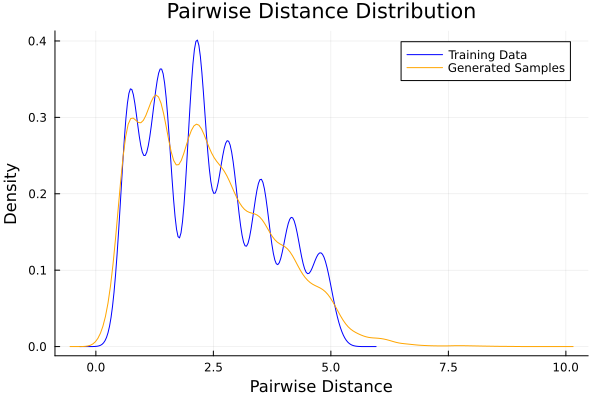

In [35]:
# Visualize the concordance of pairwise distance distributions between generated samples and training data
function visualize_distance_distributions(train_dists, gen_dists)
    # Flatten the upper triangle of the distance matrices to get 1D arrays of distances
    function upper_triangle_flat(dists)
        N = size(dists, 1)
        return [dists[i, j, b] for b in 1:size(dists, 3) for i in 1:N for j in (i+1):N]
    end
    train_flat = upper_triangle_flat(train_dists)
    gen_flat = upper_triangle_flat(gen_dists)
    # # Plot histograms
    # histogram(gen_flat, bins=50, alpha=0.5, label="Generated Samples", xlabel="Pairwise Distance", ylabel="Frequency", title="Pairwise Distance Distribution", color=:orange)
    # histogram!(train_flat, bins=50, alpha=0.5, label="Training Data", color=:blue)

    #plot density plots:
    density(train_flat, label="Training Data", xlabel="Pairwise Distance", ylabel="Density", title="Pairwise Distance Distribution", color=:blue)
    density!(gen_flat, label="Generated Samples", color=:orange)

    #legend()
end

visualize_distance_distributions(train_data_dists, gen_data_dists)


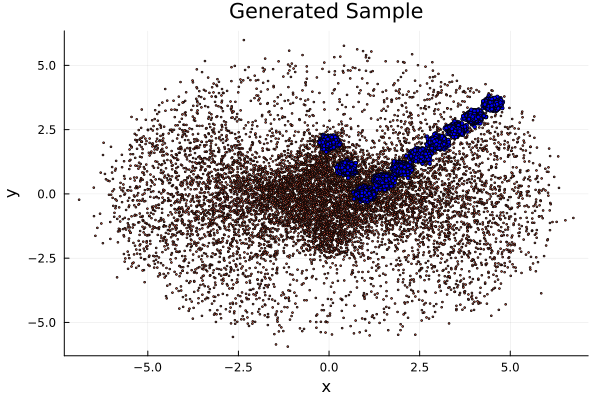

In [37]:
scatter(sample_1000[1, :, :], sample_1000[2, :, :], title="Generated Sample", xlabel="x", ylabel="y", markersize=1, markercolor=:tomato, legend=false)
scatter!(train_data[1, :, :], train_data[2, :, :], markersize=2, markercolor=:blue, legend=false)

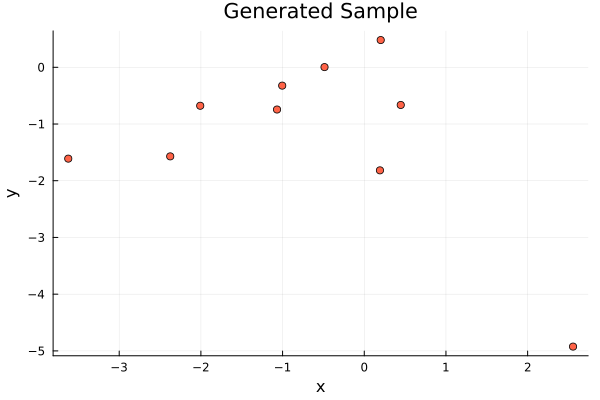

In [56]:
scatter(sample_1000[1, :, 10], sample_1000[2, :, 10], title="Generated Sample", xlabel="x", ylabel="y", markersize=4, markercolor=:tomato, legend=false)


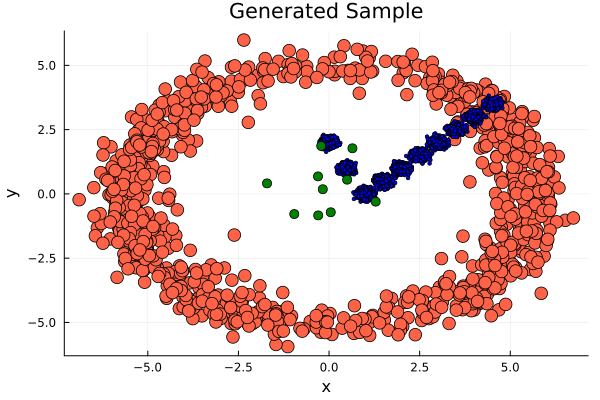

In [48]:
init_data = randn(Float32, D_dim, N_atoms, 1)
atom_no = 10
scatter(sample_1000[1, atom_no, :], sample_1000[2, atom_no, :], markersize=7, markercolor=:tomato, legend=false, title="Generated Sample", xlabel="x", ylabel="y",)
scatter!(train_data[1, :, :], train_data[2, :, :], markersize=2, markercolor=:blue, legend=false)
scatter!(init_data[1, :, :], init_data[2, :, :], markersize=5, markercolor=:green, legend=false)